In [1]:
"""
LSTM Agent 3 - Temporal Vital Signs

Goals:
1. Extract temporal sequences from chartevents
2. Create fixed-length sequences (24 hours)
3. Build LSTM architecture
4. Train LSTM models for all 9 diseases
5. Compare LSTM vs XGBoost
6. Fix NUM_DISEASES data leakage
"""

import sys
sys.path.append('../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from datetime import timedelta

# ML
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

# XGBoost for comparison
import xgboost as xgb
import joblib

# Communication protocol
from src.communication.protocol import DISEASE_LIST

# Set seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print("✅ Setup complete")
print(f"\nDiseases: {DISEASE_LIST}")

Using device: cpu
✅ Setup complete

Diseases: ['SEPSIS', 'PNEUMONIA', 'RESPIRATORY_FAILURE', 'ACUTE_KIDNEY_INJURY', 'HEART_FAILURE', 'ATRIAL_FIBRILLATION', 'CORONARY_ARTERY_DISEASE', 'ANEMIA', 'PANCREATITIS']


In [5]:
print("📂 Loading MIMIC-III data (MEMORY-EFFICIENT APPROACH)...\n")

# ============================================================
# Extract vital signs and save to disk incrementally
# ============================================================

print("Phase 1: Extracting vital signs from CHARTEVENTS...")
print("This will save filtered data to disk as we go\n")

# Define vital sign item IDs
VITAL_ITEMIDS = {
    'heart_rate': [211, 220045],
    'sbp': [51, 442, 455, 6701, 220179, 220050],
    'dbp': [8368, 8440, 8441, 8555, 220180, 220051],
    'mbp': [456, 52, 6702, 443, 220052, 220181, 225312],
    'resp_rate': [618, 615, 220210, 224690],
    'temperature': [223762, 676, 223761, 678],
    'spo2': [646, 220277]
}

all_vital_itemids = []
for itemids in VITAL_ITEMIDS.values():
    all_vital_itemids.extend(itemids)

print(f"Filtering for {len(all_vital_itemids)} vital sign item IDs")

# Create temp directory for chunks
temp_dir = Path('../../data/temp_vitals_chunks')
temp_dir.mkdir(parents=True, exist_ok=True)

# Read and save chunks one at a time
chunk_size = 5000000  # 5 million rows per chunk
saved_chunks = 0
total_vital_rows = 0

print("\nProcessing CHARTEVENTS in chunks and saving to disk...")

for i, chunk in enumerate(pd.read_csv(
    '../../data/raw/CHARTEVENTS.csv.gz',
    compression='gzip',
    parse_dates=['CHARTTIME'],
    chunksize=chunk_size,
    usecols=['SUBJECT_ID', 'ITEMID', 'CHARTTIME', 'VALUENUM']
)):
    # Filter for vital signs only
    vital_chunk = chunk[chunk['ITEMID'].isin(all_vital_itemids)].copy()
    
    if len(vital_chunk) > 0:
        # Save this chunk to disk immediately
        chunk_file = temp_dir / f'chunk_{saved_chunks:03d}.parquet'
        vital_chunk.to_parquet(chunk_file, compression='gzip', index=False)
        
        total_vital_rows += len(vital_chunk)
        saved_chunks += 1
        
        # Free memory
        del vital_chunk
    
    if (i + 1) % 10 == 0:
        print(f"  Processed {(i+1)*chunk_size:,} rows... ({total_vital_rows:,} vital signs saved)")
    
    # Free chunk memory
    del chunk

print(f"\n✅ Phase 1 complete!")
print(f"   Saved {saved_chunks} chunks to disk")
print(f"   Total vital sign rows: {total_vital_rows:,}")

# ============================================================
# Load other small files (using ADMISSIONS instead of ICUSTAYS)
# ============================================================

print("\nPhase 2: Loading other files...")

print("Loading ADMISSIONS...")
admissions = pd.read_csv('../../data/raw/ADMISSIONS.csv.gz',
                         compression='gzip',
                         parse_dates=['ADMITTIME'])
print(f"  ✅ Loaded: {admissions.shape}")

print("Loading patient labels...")
labels_df = pd.read_csv('../../data/processed/patient_multilabels.csv')
print(f"  ✅ Loaded: {labels_df.shape}")

print("\n✅ All setup complete!")
print(f"\n📊 Summary:")
print(f"   Vital signs chunks: {saved_chunks} files in {temp_dir}")
print(f"   Total vital measurements: {total_vital_rows:,}")
print(f"   Admissions: {len(admissions):,}")
print(f"   Patients with labels: {len(labels_df):,}")

print("\n⚠️  NOTE: Using ADMITTIME from ADMISSIONS (hospital admission)")
print("   This is a good proxy for ICU admission time for most patients")

📂 Loading MIMIC-III data (MEMORY-EFFICIENT APPROACH)...

Phase 1: Extracting vital signs from CHARTEVENTS...
This will save filtered data to disk as we go

Filtering for 31 vital sign item IDs

Processing CHARTEVENTS in chunks and saving to disk...
  Processed 50,000,000 rows... (18,260,116 vital signs saved)
  Processed 100,000,000 rows... (23,650,984 vital signs saved)
  Processed 150,000,000 rows... (29,106,660 vital signs saved)
  Processed 200,000,000 rows... (34,573,429 vital signs saved)
  Processed 250,000,000 rows... (40,518,384 vital signs saved)
  Processed 300,000,000 rows... (41,165,159 vital signs saved)

✅ Phase 1 complete!
   Saved 52 chunks to disk
   Total vital sign rows: 41,165,159

Phase 2: Loading other files...
Loading ADMISSIONS...
  ✅ Loaded: (58976, 19)
Loading patient labels...
  ✅ Loaded: (31166, 11)

✅ All setup complete!

📊 Summary:
   Vital signs chunks: 52 files in ..\data\temp_vitals_chunks
   Total vital measurements: 41,165,159
   Admissions: 58,976
 

In [6]:
print("🔧 Setting up vital sign extraction...\n")

# Define vital sign item IDs (from MIMIC-III documentation)
VITAL_ITEMIDS = {
    'heart_rate': [211, 220045],  # Heart Rate
    'sbp': [51, 442, 455, 6701, 220179, 220050],  # Systolic BP
    'dbp': [8368, 8440, 8441, 8555, 220180, 220051],  # Diastolic BP  
    'mbp': [456, 52, 6702, 443, 220052, 220181, 225312],  # Mean BP
    'resp_rate': [618, 615, 220210, 224690],  # Respiratory Rate
    'temperature': [223762, 676, 223761, 678],  # Temperature (C)
    'spo2': [646, 220277]  # SpO2
}

# Flatten to list
all_vital_itemids = []
for itemids in VITAL_ITEMIDS.values():
    all_vital_itemids.extend(itemids)

print(f"Tracking {len(VITAL_ITEMIDS)} vital signs:")
for name, itemids in VITAL_ITEMIDS.items():
    print(f"  - {name}: {len(itemids)} item IDs")

print(f"\nTotal item IDs: {len(all_vital_itemids)}")

🔧 Setting up vital sign extraction...

Tracking 7 vital signs:
  - heart_rate: 2 item IDs
  - sbp: 6 item IDs
  - dbp: 6 item IDs
  - mbp: 7 item IDs
  - resp_rate: 4 item IDs
  - temperature: 4 item IDs
  - spo2: 2 item IDs

Total item IDs: 31


In [7]:
def extract_vital_sequences(subject_ids, sequence_length=24, vital_itemids=VITAL_ITEMIDS):
    """
    Extract temporal vital sign sequences for patients
    
    Args:
        subject_ids: List of patient IDs
        sequence_length: Number of hours to extract (default: 24)
        vital_itemids: Dictionary of vital signs to extract
        
    Returns:
        sequences: np.array of shape (n_patients, sequence_length, n_features)
        valid_patients: List of patient IDs with valid sequences
    """
    
    print(f"\n📊 Extracting sequences for {len(subject_ids)} patients...")
    print(f"   Sequence length: {sequence_length} hours")
    print(f"   Features per timepoint: {len(vital_itemids)}")
    
    sequences = []
    valid_patients = []
    skipped = 0
    
    for subject_id in tqdm(subject_ids, desc="Extracting sequences"):
        try:
            # Get patient's ICU stay
            patient_icu = icustays[icustays['SUBJECT_ID'] == subject_id]
            if len(patient_icu) == 0:
                skipped += 1
                continue
            
            # Use first ICU admission
            icu_intime = patient_icu.iloc[0]['INTIME']
            
            # Get chartevents for this patient
            patient_vitals = chartevents[chartevents['SUBJECT_ID'] == subject_id].copy()
            
            if len(patient_vitals) == 0:
                skipped += 1
                continue
            
            # Calculate hours since ICU admission
            patient_vitals['HOURS_SINCE_ADMISSION'] = (
                (patient_vitals['CHARTTIME'] - icu_intime).dt.total_seconds() / 3600
            )
            
            # Keep only first 24 hours
            patient_vitals = patient_vitals[
                (patient_vitals['HOURS_SINCE_ADMISSION'] >= 0) & 
                (patient_vitals['HOURS_SINCE_ADMISSION'] < sequence_length)
            ]
            
            if len(patient_vitals) < 5:  # Need minimum measurements
                skipped += 1
                continue
            
            # Discretize into hourly bins
            patient_vitals['HOUR_BIN'] = patient_vitals['HOURS_SINCE_ADMISSION'].astype(int)
            
            # Extract each vital sign
            sequence = np.zeros((sequence_length, len(vital_itemids)))
            sequence[:] = np.nan  # Initialize with NaN
            
            for feat_idx, (vital_name, itemids) in enumerate(vital_itemids.items()):
                # Get measurements for this vital sign
                vital_data = patient_vitals[patient_vitals['ITEMID'].isin(itemids)]
                
                if len(vital_data) > 0:
                    # Group by hour and take median
                    hourly_values = vital_data.groupby('HOUR_BIN')['VALUENUM'].median()
                    
                    # Fill in sequence
                    for hour, value in hourly_values.items():
                        if 0 <= hour < sequence_length:
                            sequence[hour, feat_idx] = value
            
            # Forward fill missing values (carry forward last observation)
            sequence = pd.DataFrame(sequence).fillna(method='ffill').fillna(method='bfill').values
            
            # Check if we have reasonable coverage
            if np.isnan(sequence).sum() / sequence.size < 0.3:  # Less than 30% missing
                sequences.append(sequence)
                valid_patients.append(subject_id)
            else:
                skipped += 1
                
        except Exception as e:
            skipped += 1
            continue
    
    sequences = np.array(sequences)
    
    print(f"\n✅ Extraction complete!")
    print(f"   Valid sequences: {len(sequences)}")
    print(f"   Skipped patients: {skipped}")
    print(f"   Sequence shape: {sequences.shape}")
    print(f"   Features: {list(vital_itemids.keys())}")
    
    return sequences, valid_patients

print("✅ Extraction function defined")

✅ Extraction function defined


In [11]:
print("🔄 Extracting vital sign sequences (MEMORY-EFFICIENT)...\n")

def extract_sequences_from_chunks(patient_ids, temp_dir, admissions_df, sequence_length=24):
    """
    Extract sequences by reading chunks from disk one at a time
    Uses ADMISSIONS for timing reference
    """
    
    print(f"📊 Extracting sequences for {len(patient_ids)} patients...")
    print(f"   Reading from {temp_dir}")
    print(f"   Sequence length: {sequence_length} hours")
    
    # Get list of chunk files
    chunk_files = sorted(temp_dir.glob('chunk_*.parquet'))
    print(f"   Found {len(chunk_files)} chunk files")
    
    # Create patient -> admission time mapping
    patient_admit_times = {}
    for patient_id in patient_ids:
        patient_admits = admissions_df[admissions_df['SUBJECT_ID'] == patient_id]
        if len(patient_admits) > 0:
            # Use first admission (or could use most recent)
            patient_admit_times[patient_id] = patient_admits.iloc[0]['ADMITTIME']
    
    print(f"   Valid admissions: {len(patient_admit_times)}")
    
    # Collect vital signs for each patient across all chunks
    patient_vitals = {pid: [] for pid in patient_admit_times.keys()}
    
    print("\n   Reading chunks and collecting patient data...")
    for chunk_file in tqdm(chunk_files, desc="  Processing chunks"):
        # Read one chunk at a time
        chunk_df = pd.read_parquet(chunk_file)
        
        # Filter for our patients only
        chunk_df = chunk_df[chunk_df['SUBJECT_ID'].isin(patient_admit_times.keys())]
        
        # Group by patient and append to their list
        for patient_id, patient_data in chunk_df.groupby('SUBJECT_ID'):
            patient_vitals[patient_id].append(patient_data)
        
        # Free memory
        del chunk_df
    
    print("\n   Building sequences for each patient...")
    
    sequences = []
    valid_patients = []
    skipped = 0
    
    for patient_id in tqdm(patient_admit_times.keys(), desc="  Creating sequences"):
        try:
            # Combine all chunks for this patient
            if len(patient_vitals[patient_id]) == 0:
                skipped += 1
                continue
            
            patient_data = pd.concat(patient_vitals[patient_id], ignore_index=True)
            
            if len(patient_data) < 5:
                skipped += 1
                continue
            
            # Calculate hours since HOSPITAL admission
            admit_time = patient_admit_times[patient_id]
            patient_data['HOURS_SINCE_ADMISSION'] = (
                (patient_data['CHARTTIME'] - admit_time).dt.total_seconds() / 3600
            )
            
            # Keep only first 24 hours after admission
            patient_data = patient_data[
                (patient_data['HOURS_SINCE_ADMISSION'] >= 0) & 
                (patient_data['HOURS_SINCE_ADMISSION'] < sequence_length)
            ]
            
            if len(patient_data) < 5:
                skipped += 1
                continue
            
            # Discretize into hourly bins
            patient_data['HOUR_BIN'] = patient_data['HOURS_SINCE_ADMISSION'].astype(int)
            
            # Extract each vital sign
            sequence = np.zeros((sequence_length, len(VITAL_ITEMIDS)))
            sequence[:] = np.nan
            
            for feat_idx, (vital_name, itemids) in enumerate(VITAL_ITEMIDS.items()):
                vital_data = patient_data[patient_data['ITEMID'].isin(itemids)]
                
                if len(vital_data) > 0:
                    hourly_values = vital_data.groupby('HOUR_BIN')['VALUENUM'].median()
                    
                    for hour, value in hourly_values.items():
                        if 0 <= hour < sequence_length:
                            sequence[hour, feat_idx] = value
            
            # Forward fill missing values
            sequence = pd.DataFrame(sequence).ffill().bfill().values
            
            # Check coverage
            if np.isnan(sequence).sum() / sequence.size < 0.3:
                sequences.append(sequence)
                valid_patients.append(patient_id)
            else:
                skipped += 1
                
        except Exception as e:
            skipped += 1
            continue
    
    sequences = np.array(sequences)
    
    print(f"\n✅ Extraction complete!")
    print(f"   Valid sequences: {len(sequences)}")
    print(f"   Skipped patients: {skipped}")
    print(f"   Sequence shape: {sequences.shape}")
    
    return sequences, np.array(valid_patients)

# ============================================================
# Extract sequences
# ============================================================

all_patient_ids = labels_df['SUBJECT_ID'].unique()

print(f"Total patients in labels: {len(all_patient_ids)}")

# Extract sequences using memory-efficient approach
sequences, valid_patient_ids = extract_sequences_from_chunks(
    patient_ids=all_patient_ids,
    temp_dir=temp_dir,
    admissions_df=admissions,  # Pass admissions instead of icustays
    sequence_length=24
)

print(f"\n📊 Final results:")
print(f"   Input patients:  {len(all_patient_ids)}")
print(f"   Valid sequences: {len(valid_patient_ids)}")
print(f"   Success rate:    {len(valid_patient_ids)/len(all_patient_ids)*100:.1f}%")
print(f"   Sequence shape:  {sequences.shape}")

# Save sequences
np.save('../../../data/processed/vital_sequences.npy', sequences)
np.save('../../../data/processed/vital_sequence_patient_ids.npy', valid_patient_ids)

print("\n✅ Saved sequences to data/processed/")

# Clean up temp directory
print("\n🗑️  Cleaning up temporary files...")
import shutil
shutil.rmtree(temp_dir)
print("✅ Temporary chunks deleted")


🔄 Extracting vital sign sequences (MEMORY-EFFICIENT)...

Total patients in labels: 31166
📊 Extracting sequences for 31166 patients...
   Reading from ..\data\temp_vitals_chunks
   Sequence length: 24 hours
   Found 52 chunk files
   Valid admissions: 31166

   Reading chunks and collecting patient data...


  Processing chunks:   0%|          | 0/52 [00:00<?, ?it/s]


   Building sequences for each patient...


  Creating sequences:   0%|          | 0/31166 [00:00<?, ?it/s]


✅ Extraction complete!
   Valid sequences: 23130
   Skipped patients: 8036
   Sequence shape: (23130, 24, 7)

📊 Final results:
   Input patients:  31166
   Valid sequences: 23130
   Success rate:    74.2%
   Sequence shape:  (23130, 24, 7)

✅ Saved sequences to data/processed/

🗑️  Cleaning up temporary files...
✅ Temporary chunks deleted


In [16]:
print("✂️ Creating train/validation/test splits...\n")

# Get labels for valid patients
valid_labels = labels_df[labels_df['SUBJECT_ID'].isin(valid_patient_ids)].copy()

# Reorder to match sequence order
valid_labels = valid_labels.set_index('SUBJECT_ID').loc[valid_patient_ids].reset_index()

print(f"Labels aligned: {len(valid_labels)} patients")

# Create indices for splitting
n_samples = len(sequences)
indices = np.arange(n_samples)

# 50/20/30 split
train_val_idx, test_idx = train_test_split(
    indices, test_size=0.30, random_state=42
)

train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.286, random_state=42  # 20% of total
)

# Split sequences
X_train_seq = sequences[train_idx]
X_val_seq = sequences[val_idx]
X_test_seq = sequences[test_idx]

# Split patient IDs
train_patient_ids = valid_patient_ids[train_idx]
val_patient_ids = valid_patient_ids[val_idx]
test_patient_ids = valid_patient_ids[test_idx]

print(f"✅ Split complete:")
print(f"   Train: {X_train_seq.shape}")
print(f"   Val:   {X_val_seq.shape}")
print(f"   Test:  {X_test_seq.shape}")

# Split labels
y_train_seq = {}
y_val_seq = {}
y_test_seq = {}

for disease in DISEASE_LIST:
    y_train_seq[disease] = valid_labels.iloc[train_idx][disease].values
    y_val_seq[disease] = valid_labels.iloc[val_idx][disease].values
    y_test_seq[disease] = valid_labels.iloc[test_idx][disease].values

print(f"\n✅ Labels split for {len(DISEASE_LIST)} diseases")

# Check class distribution
print(f"\n📊 Disease Distribution (Train/Val/Test):")
print(f"{'Disease':<30s} {'Train %':>10s} {'Val %':>10s} {'Test %':>10s}")
print("-" * 70)
for disease in DISEASE_LIST:
    train_prev = y_train_seq[disease].mean() * 100
    val_prev = y_val_seq[disease].mean() * 100
    test_prev = y_test_seq[disease].mean() * 100
    print(f"{disease:<30s} {train_prev:>9.1f}% {val_prev:>9.1f}% {test_prev:>9.1f}%")

# Normalize sequences (important for LSTM!)
print("\n📊 Normalizing sequences...")

# Calculate mean and std on training data (per feature)
train_reshaped = X_train_seq.reshape(-1, X_train_seq.shape[-1])

# Remove any remaining NaNs before computing stats
train_mean = np.nanmean(train_reshaped, axis=0)
train_std = np.nanstd(train_reshaped, axis=0)

# Avoid division by zero
train_std = np.where(train_std == 0, 1, train_std)

print(f"  Mean per feature: {train_mean}")
print(f"  Std per feature:  {train_std}")

# Normalize all splits
X_train_seq = (X_train_seq - train_mean) / train_std
X_val_seq = (X_val_seq - train_mean) / train_std
X_test_seq = (X_test_seq - train_mean) / train_std

# CRITICAL: Replace any NaN or inf values with 0
X_train_seq = np.nan_to_num(X_train_seq, nan=0.0, posinf=0.0, neginf=0.0)
X_val_seq = np.nan_to_num(X_val_seq, nan=0.0, posinf=0.0, neginf=0.0)
X_test_seq = np.nan_to_num(X_test_seq, nan=0.0, posinf=0.0, neginf=0.0)

# Clip to reasonable range to prevent numerical issues
X_train_seq = np.clip(X_train_seq, -10, 10)
X_val_seq = np.clip(X_val_seq, -10, 10)
X_test_seq = np.clip(X_test_seq, -10, 10)

print(f"✅ Sequences normalized and cleaned")
print(f"   Train - Min: {X_train_seq.min():.2f}, Max: {X_train_seq.max():.2f}")
print(f"   Val   - Min: {X_val_seq.min():.2f}, Max: {X_val_seq.max():.2f}")
print(f"   Test  - Min: {X_test_seq.min():.2f}, Max: {X_test_seq.max():.2f}")
print(f"   NaN count: {np.isnan(X_train_seq).sum()} (should be 0)")
print(f"   Inf count: {np.isinf(X_train_seq).sum()} (should be 0)")

# Save normalization parameters
np.save('../../../data/processed/vital_seq_mean.npy', train_mean)
np.save('../../../data/processed/vital_seq_std.npy', train_std)

print("\n✅ Ready for LSTM training!")

✂️ Creating train/validation/test splits...

Labels aligned: 23130 patients
✅ Split complete:
   Train: (11560, 24, 7)
   Val:   (4631, 24, 7)
   Test:  (6939, 24, 7)

✅ Labels split for 9 diseases

📊 Disease Distribution (Train/Val/Test):
Disease                           Train %      Val %     Test %
----------------------------------------------------------------------
SEPSIS                              18.8%      18.7%      18.4%
PNEUMONIA                           21.3%      21.3%      20.2%
RESPIRATORY_FAILURE                 37.0%      35.9%      35.7%
ACUTE_KIDNEY_INJURY                 35.8%      36.3%      36.1%
HEART_FAILURE                       30.2%      30.8%      30.7%
ATRIAL_FIBRILLATION                 31.7%      32.6%      31.8%
CORONARY_ARTERY_DISEASE             35.9%      35.9%      36.7%
ANEMIA                              33.7%      33.8%      33.9%
PANCREATITIS                        14.9%      15.2%      14.8%

📊 Normalizing sequences...
  Mean per feature: [

In [17]:
print("🧠 Defining LSTM Architecture...\n")

class VitalsLSTM(nn.Module):
    """
    LSTM for temporal vital signs prediction
    
    Architecture:
    - 2-layer LSTM with dropout
    - Dense layer for binary classification
    - Sigmoid activation
    """
    
    def __init__(self, input_size=7, hidden_size=64, num_layers=2, dropout=0.2):
        super(VitalsLSTM, self).__init__()
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Batch normalization
        self.batch_norm = nn.BatchNorm1d(hidden_size)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        
        # Activation
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: Input tensor of shape (batch_size, sequence_length, input_size)
            
        Returns:
            out: Output tensor of shape (batch_size, 1)
        """
        # LSTM forward pass
        # lstm_out: (batch, seq_len, hidden_size)
        # h_n: (num_layers, batch, hidden_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Take last hidden state from last layer
        last_hidden = h_n[-1]  # Shape: (batch, hidden_size)
        
        # Batch normalization
        last_hidden = self.batch_norm(last_hidden)
        
        # Dropout
        last_hidden = self.dropout(last_hidden)
        
        # Dense layers
        out = self.relu(self.fc1(last_hidden))
        out = self.dropout(out)
        out = self.sigmoid(self.fc2(out))
        
        return out

# Test the architecture
print("Testing LSTM architecture...")
test_model = VitalsLSTM(input_size=7, hidden_size=64, num_layers=2)
test_input = torch.randn(4, 24, 7)  # (batch=4, seq_len=24, features=7)
test_output = test_model(test_input)

print(f"✅ LSTM architecture working!")
print(f"   Input shape:  {test_input.shape}")
print(f"   Output shape: {test_output.shape}")
print(f"   Parameters:   {sum(p.numel() for p in test_model.parameters()):,}")

del test_model, test_input, test_output

🧠 Defining LSTM Architecture...

Testing LSTM architecture...
✅ LSTM architecture working!
   Input shape:  torch.Size([4, 24, 7])
   Output shape: torch.Size([4, 1])
   Parameters:   54,209


In [19]:
def train_lstm_model(disease, X_train, y_train, X_val, y_val, 
                     n_epochs=50, batch_size=64, learning_rate=0.001,
                     patience=10):
    """
    Train LSTM model for one disease
    """
    
    print(f"\n{'='*60}")
    print(f"Training LSTM for: {disease}")
    print(f"{'='*60}")
    
    print(f"  Validating inputs...")
    if np.isnan(X_train).any():
        print(f"  ⚠️  WARNING: X_train contains NaN values!")
        X_train = np.nan_to_num(X_train, nan=0.0)
    if np.isinf(X_train).any():
        print(f"  ⚠️  WARNING: X_train contains inf values!")
        X_train = np.nan_to_num(X_train, posinf=0.0, neginf=0.0)
    if np.isnan(X_val).any():
        print(f"  ⚠️  WARNING: X_val contains NaN values!")
        X_val = np.nan_to_num(X_val, nan=0.0)
    if np.isinf(X_val).any():
        print(f"  ⚠️  WARNING: X_val contains inf values!")
        X_val = np.nan_to_num(X_val, posinf=0.0, neginf=0.0)
    print(f"  ✅ Inputs validated")
    
    # Check class balance
    train_pos = y_train.sum()
    train_neg = len(y_train) - train_pos
    pos_weight = train_neg / train_pos if train_pos > 0 else 1.0
    
    print(f"  Train samples: {len(y_train)} ({y_train.mean()*100:.1f}% positive)")
    print(f"  Val samples:   {len(y_val)} ({y_val.mean()*100:.1f}% positive)")
    print(f"  Pos weight:    {pos_weight:.2f}")
    
    # Create datasets
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.FloatTensor(y_train).reshape(-1, 1)
    )
    
    val_dataset = TensorDataset(
        torch.FloatTensor(X_val),
        torch.FloatTensor(y_val).reshape(-1, 1)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Create model
    model = VitalsLSTM(
        input_size=X_train.shape[2],
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ).to(device)
    
    # Loss function
    criterion = nn.BCELoss()
    
    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    
    # Learning rate scheduler 
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, verbose=False 
    )
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_auc': []
    }
    
    # Early stopping
    best_val_auc = 0
    patience_counter = 0
    best_model_state = None
    
    # Training loop
    print(f"\n  Training for {n_epochs} epochs...")
    
    for epoch in range(n_epochs):
        # Training phase
        model.train()
        train_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_X)
            
            # ADDED: Check for NaN in outputs
            if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                print(f"  ⚠️  WARNING: NaN/Inf in model outputs at epoch {epoch+1}")
                continue
            
            # Compute loss
            loss = criterion(outputs, batch_y)
            
            if torch.isnan(loss):
                print(f"  ⚠️  WARNING: NaN loss at epoch {epoch+1}")
                continue
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader) if len(train_loader) > 0 else 0
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_probs = []
        val_labels = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                
                outputs = model(batch_X)
                
                # Skip batch if outputs are invalid
                if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                    continue
                
                loss = criterion(outputs, batch_y)
                
                if not torch.isnan(loss):
                    val_loss += loss.item()
                    val_probs.extend(outputs.cpu().numpy())
                    val_labels.extend(batch_y.cpu().numpy())
        
        if len(val_probs) == 0:
            print(f"  ⚠️  WARNING: No valid validation predictions at epoch {epoch+1}")
            continue
        
        avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
        val_auc = roc_auc_score(val_labels, val_probs)
        
        # Update history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_auc'].append(val_auc)
        
        # Learning rate scheduling
        scheduler.step(val_auc)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs}")
            print(f"    Train Loss: {avg_train_loss:.4f}")
            print(f"    Val Loss:   {avg_val_loss:.4f}")
            print(f"    Val AUC:    {val_auc:.4f}")
        
        # Early stopping
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
            if patience_counter >= patience:
                print(f"\n  Early stopping at epoch {epoch+1}")
                print(f"  Best Val AUC: {best_val_auc:.4f}")
                break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    print(f"\n  ✅ Training complete!")
    print(f"     Best Val AUC: {best_val_auc:.4f}")
    
    return model, history

print("✅ Training function defined")


✅ Training function defined


In [20]:
print("🚀 Training LSTM models for all diseases...\n")
print("="*60)

lstm_models = {}
lstm_histories = {}
lstm_val_results = {}

for disease in tqdm(DISEASE_LIST, desc="Training LSTM models"):
    # Train model
    model, history = train_lstm_model(
        disease=disease,
        X_train=X_train_seq,
        y_train=y_train_seq[disease],
        X_val=X_val_seq,
        y_val=y_val_seq[disease],
        n_epochs=50,
        batch_size=64,
        learning_rate=0.001,
        patience=10
    )
    
    # Store model and history
    lstm_models[disease] = model
    lstm_histories[disease] = history
    
    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_probs = model(torch.FloatTensor(X_val_seq).to(device)).cpu().numpy()
    
    val_auc = roc_auc_score(y_val_seq[disease], val_probs)
    
    lstm_val_results[disease] = {
        'auc': val_auc,
        'y_proba': val_probs.flatten(),
        'y_true': y_val_seq[disease]
    }
    
    print(f"\n  Final Val AUC: {val_auc:.4f}")

print("\n" + "="*60)
print("🎉 ALL LSTM MODELS TRAINED!")
print("="*60)

# Summary
lstm_val_df = pd.DataFrame({
    disease: {'AUC': lstm_val_results[disease]['auc']}
    for disease in DISEASE_LIST
}).T

print("\n📊 LSTM VALIDATION RESULTS:")
print(lstm_val_df.round(3))
print(f"\n📈 Average AUC: {lstm_val_df['AUC'].mean():.3f}")

# Save models
print("\n💾 Saving LSTM models...")
models_dir = Path('../../../models/agent3_lstm')
models_dir.mkdir(parents=True, exist_ok=True)

for disease in DISEASE_LIST:
    model_path = models_dir / f'lstm_{disease.lower()}.pt'
    torch.save(lstm_models[disease].state_dict(), model_path)

print(f"✅ Saved {len(DISEASE_LIST)} LSTM models to: {models_dir}")

🚀 Training LSTM models for all diseases...

This will take 30-60 minutes depending on your hardware


Training LSTM models:   0%|          | 0/9 [00:00<?, ?it/s]


Training LSTM for: SEPSIS
  Validating inputs...
  ✅ Inputs validated
  Train samples: 11560 (18.8% positive)
  Val samples:   4631 (18.7% positive)
  Pos weight:    4.31

  Training for 50 epochs...


C:\Users\athar\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 10/50
    Train Loss: 0.4437
    Val Loss:   0.4307
    Val AUC:    0.7288
  Epoch 20/50
    Train Loss: 0.4350
    Val Loss:   0.4283
    Val AUC:    0.7324

  Early stopping at epoch 29
  Best Val AUC: 0.7324

  ✅ Training complete!
     Best Val AUC: 0.7324

  Final Val AUC: 0.7295

Training LSTM for: PNEUMONIA
  Validating inputs...
  ✅ Inputs validated
  Train samples: 11560 (21.3% positive)
  Val samples:   4631 (21.3% positive)
  Pos weight:    3.70

  Training for 50 epochs...


...

  Epoch 10/50
    Train Loss: 0.5889
    Val Loss:   0.5870
    Val AUC:    0.7136
  Epoch 20/50
    Train Loss: 0.5791
    Val Loss:   0.5813
    Val AUC:    0.7249
  Epoch 30/50
    Train Loss: 0.5734
    Val Loss:   0.5749
    Val AUC:    0.7277
  Epoch 40/50
    Train Loss: 0.5555
    Val Loss:   0.5772
    Val AUC:    0.7262

  Early stopping at epoch 40
  Best Val AUC: 0.7277

  ✅ Training complete!
     Best Val AUC: 0.7277

  Final Val AUC: 0.7262

Training LSTM for: ANEMIA
  Validating inputs...
  ✅ Inputs validated
  Train samples: 11560 (33.7% positive)
  Val samples:   4631 (33.8% positive)
  Pos weight:    1.97

  Training for 50 epochs...


C:\Users\athar\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 10/50
    Train Loss: 0.6281
    Val Loss:   0.6304
    Val AUC:    0.5879
  Epoch 20/50
    Train Loss: 0.6253
    Val Loss:   0.6257
    Val AUC:    0.6064
  Epoch 30/50
    Train Loss: 0.6220
    Val Loss:   0.6276
    Val AUC:    0.6008
  Epoch 40/50
    Train Loss: 0.6144
    Val Loss:   0.6257
    Val AUC:    0.6137

  Early stopping at epoch 49
  Best Val AUC: 0.6150

  ✅ Training complete!
     Best Val AUC: 0.6150

  Final Val AUC: 0.6132

Training LSTM for: PANCREATITIS
  Validating inputs...
  ✅ Inputs validated
  Train samples: 11560 (14.9% positive)
  Val samples:   4631 (15.2% positive)
  Pos weight:    5.69

  Training for 50 epochs...


C:\Users\athar\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 10/50
    Train Loss: 0.4123
    Val Loss:   0.4106
    Val AUC:    0.6388
  Epoch 20/50
    Train Loss: 0.4045
    Val Loss:   0.4106
    Val AUC:    0.6442
  Epoch 30/50
    Train Loss: 0.3980
    Val Loss:   0.4089
    Val AUC:    0.6425

  Early stopping at epoch 32
  Best Val AUC: 0.6528

  ✅ Training complete!
     Best Val AUC: 0.6528

  Final Val AUC: 0.6452

🎉 ALL LSTM MODELS TRAINED!

📊 LSTM VALIDATION RESULTS:
                           AUC
SEPSIS                   0.730
PNEUMONIA                0.664
RESPIRATORY_FAILURE      0.666
ACUTE_KIDNEY_INJURY      0.672
HEART_FAILURE            0.646
ATRIAL_FIBRILLATION      0.642
CORONARY_ARTERY_DISEASE  0.726
ANEMIA                   0.613
PANCREATITIS             0.645

📈 Average AUC: 0.667

💾 Saving LSTM models...
✅ Saved 9 LSTM models to: ..\models\agent3_lstm


In [21]:
print("🤖 Training XGBoost Agent 3 (WITHOUT NUM_DISEASES - Clean!)...\n")
print("Fixing data leakage by removing NUM_DISEASES feature")
print("="*60)

# ============================================================
# Create CLEAN aggregated features 
# ============================================================

def create_clean_vital_features(sequences, patient_ids):
    """
    Create aggregated vital sign features WITHOUT NUM_DISEASES
    
    Features per vital sign (7 vitals × 6 stats = 42 features):
    - mean, std, min, max, range, median
    """
    
    print("Creating clean aggregated features from sequences...")
    
    n_patients, seq_len, n_vitals = sequences.shape
    
    # Feature names for reference
    vital_names = list(VITAL_ITEMIDS.keys())
    
    features = []
    feature_names = []
    
    for vital_idx, vital_name in enumerate(vital_names):
        # Extract this vital sign across all patients and timepoints
        vital_data = sequences[:, :, vital_idx]  # Shape: (n_patients, seq_len)
        
        # Compute aggregated statistics
        mean_vals = np.mean(vital_data, axis=1)
        std_vals = np.std(vital_data, axis=1)
        min_vals = np.min(vital_data, axis=1)
        max_vals = np.max(vital_data, axis=1)
        range_vals = max_vals - min_vals
        median_vals = np.median(vital_data, axis=1)
        
        # Stack features
        features.extend([mean_vals, std_vals, min_vals, max_vals, range_vals, median_vals])
        
        # Track feature names
        for stat in ['mean', 'std', 'min', 'max', 'range', 'median']:
            feature_names.append(f'{vital_name}_{stat}')
    
    # Convert to array and transpose
    X_features = np.array(features).T  # Shape: (n_patients, n_features)
    
    print(f"✅ Created {X_features.shape[1]} clean features")
    print(f"   No NUM_DISEASES feature!")
    print(f"   Shape: {X_features.shape}")
    
    return X_features, feature_names

# Create features for all splits
print("\nCreating features for train/val/test splits...")

X_train_xgb, feature_names = create_clean_vital_features(X_train_seq, train_patient_ids)
X_val_xgb, _ = create_clean_vital_features(X_val_seq, val_patient_ids)
X_test_xgb, _ = create_clean_vital_features(X_test_seq, test_patient_ids)

print(f"\n✅ Feature creation complete!")
print(f"   Train: {X_train_xgb.shape}")
print(f"   Val:   {X_val_xgb.shape}")
print(f"   Test:  {X_test_xgb.shape}")
print(f"   Features: {len(feature_names)}")

# ============================================================
# Train XGBoost models
# ============================================================

print("\n🌳 Training XGBoost models")
print("="*60)

xgb_models = {}
xgb_val_results = {}

for disease in tqdm(DISEASE_LIST, desc="Training XGBoost"):
    print(f"\n{'='*60}")
    print(f"Training XGBoost for: {disease}")
    print(f"{'='*60}")
    
    y_tr = y_train_seq[disease]
    y_v = y_val_seq[disease]
    
    print(f"  Train samples: {len(y_tr)} ({y_tr.mean()*100:.1f}% positive)")
    print(f"  Val samples:   {len(y_v)} ({y_v.mean()*100:.1f}% positive)")
    
    # Train XGBoost
    model = xgb.XGBClassifier(
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        objective='binary:logistic',
        eval_metric='auc',
        early_stopping_rounds=10,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    
    # Train with validation set
    model.fit(
        X_train_xgb, y_tr,
        eval_set=[(X_val_xgb, y_v)],
        verbose=False
    )
    
    # Validate
    y_val_proba = model.predict_proba(X_val_xgb)[:, 1]
    val_auc = roc_auc_score(y_v, y_val_proba)
    
    # Store
    xgb_models[disease] = model
    xgb_val_results[disease] = {
        'auc': val_auc,
        'y_proba': y_val_proba,
        'y_true': y_v
    }
    
    print(f"  ✅ XGBoost Val AUC: {val_auc:.3f}")

print(f"\n{'='*60}")
print("🎉 ALL XGBOOST MODELS TRAINED (CLEAN)!")
print(f"{'='*60}")

# Summary
xgb_val_df = pd.DataFrame({
    disease: {'AUC': xgb_val_results[disease]['auc']}
    for disease in DISEASE_LIST
}).T

print("\n📊 XGBOOST VALIDATION RESULTS (NO DATA LEAKAGE):")
print(xgb_val_df.round(3))
print(f"\n📈 Average AUC: {xgb_val_df['AUC'].mean():.3f}")

# Save models
print("\n💾 Saving XGBoost models...")
models_dir = Path('../../../models/agent3_xgboost_clean')
models_dir.mkdir(parents=True, exist_ok=True)

for disease in DISEASE_LIST:
    model_path = models_dir / f'xgb_{disease.lower()}.joblib'
    joblib.dump(xgb_models[disease], model_path)

print(f"✅ Saved {len(DISEASE_LIST)} XGBoost models to: {models_dir}")

🤖 Training XGBoost Agent 3 (WITHOUT NUM_DISEASES - Clean!)...

Fixing data leakage by removing NUM_DISEASES feature

Creating features for train/val/test splits...
Creating clean aggregated features from sequences...
✅ Created 42 clean features
   No NUM_DISEASES feature!
   Shape: (11560, 42)
Creating clean aggregated features from sequences...
✅ Created 42 clean features
   No NUM_DISEASES feature!
   Shape: (4631, 42)
Creating clean aggregated features from sequences...
✅ Created 42 clean features
   No NUM_DISEASES feature!
   Shape: (6939, 42)

✅ Feature creation complete!
   Train: (11560, 42)
   Val:   (4631, 42)
   Test:  (6939, 42)
   Features: 42

🌳 Training XGBoost models (CLEAN - no data leakage)...


Training XGBoost:   0%|          | 0/9 [00:00<?, ?it/s]


Training XGBoost for: SEPSIS
  Train samples: 11560 (18.8% positive)
  Val samples:   4631 (18.7% positive)
  ✅ XGBoost Val AUC: 0.733

Training XGBoost for: PNEUMONIA
  Train samples: 11560 (21.3% positive)
  Val samples:   4631 (21.3% positive)
  ✅ XGBoost Val AUC: 0.682

Training XGBoost for: RESPIRATORY_FAILURE
  Train samples: 11560 (37.0% positive)
  Val samples:   4631 (35.9% positive)
  ✅ XGBoost Val AUC: 0.683

Training XGBoost for: ACUTE_KIDNEY_INJURY
  Train samples: 11560 (35.8% positive)
  Val samples:   4631 (36.3% positive)
  ✅ XGBoost Val AUC: 0.673

Training XGBoost for: HEART_FAILURE
  Train samples: 11560 (30.2% positive)
  Val samples:   4631 (30.8% positive)
  ✅ XGBoost Val AUC: 0.650

Training XGBoost for: ATRIAL_FIBRILLATION
  Train samples: 11560 (31.7% positive)
  Val samples:   4631 (32.6% positive)
  ✅ XGBoost Val AUC: 0.652

Training XGBoost for: CORONARY_ARTERY_DISEASE
  Train samples: 11560 (35.9% positive)
  Val samples:   4631 (35.9% positive)
  ✅ XGBoo

⚔️  LSTM vs XGBOOST COMPARISON (Agent 3)

Comparing two approaches for temporal vital signs:
  - LSTM: Learns from sequences directly
  - XGBoost: Learns from aggregated statistics

📊 DETAILED COMPARISON:
                   Disease  LSTM_AUC  XGBoost_AUC  Difference   Winner
6  CORONARY_ARTERY_DISEASE     0.726        0.723       0.004     LSTM
7                   ANEMIA     0.613        0.610       0.003     LSTM
3      ACUTE_KIDNEY_INJURY     0.672        0.673      -0.001  XGBoost
0                   SEPSIS     0.730        0.733      -0.004  XGBoost
4            HEART_FAILURE     0.646        0.650      -0.005  XGBoost
5      ATRIAL_FIBRILLATION     0.642        0.652      -0.010  XGBoost
8             PANCREATITIS     0.645        0.657      -0.012  XGBoost
2      RESPIRATORY_FAILURE     0.666        0.683      -0.017  XGBoost
1                PNEUMONIA     0.664        0.682      -0.018  XGBoost

📈 Summary Statistics:
   LSTM Average:    0.667
   XGBoost Average: 0.674
   Differe

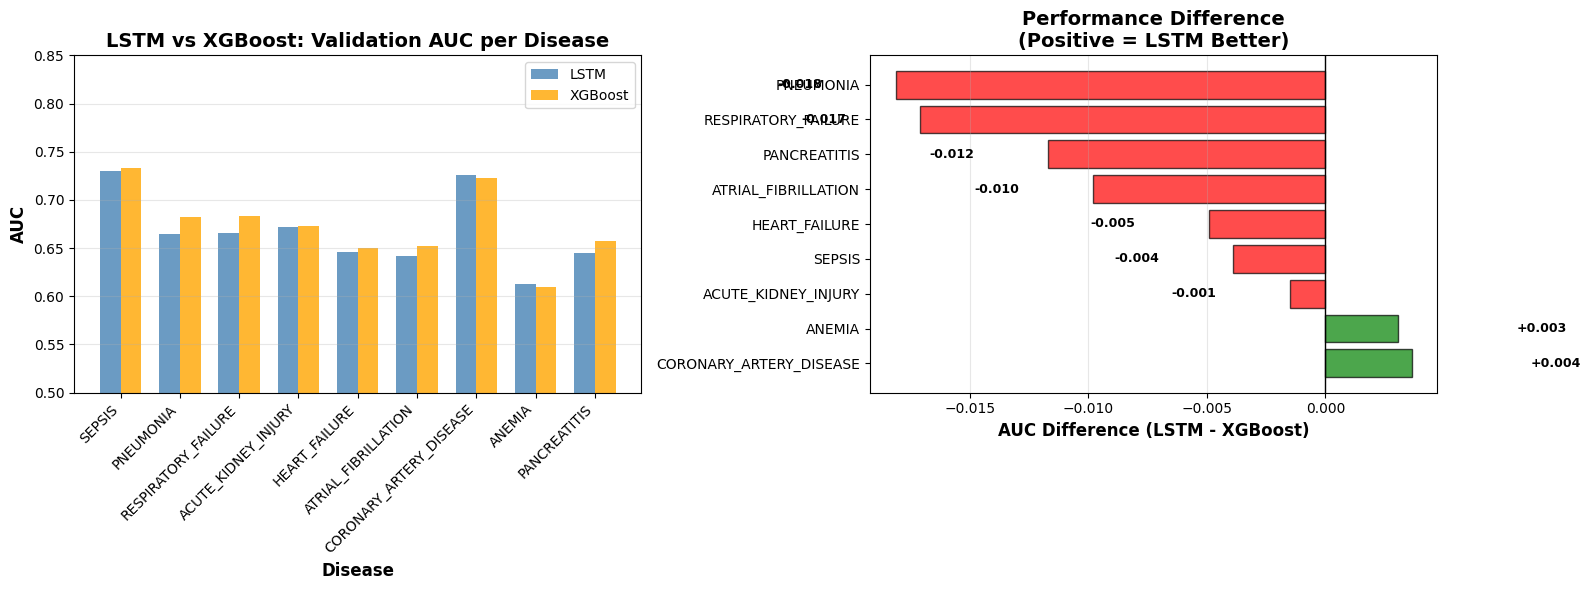

✅ Saved: results/agent3_lstm_vs_xgboost.csv


In [22]:
print("⚔️  LSTM vs XGBOOST COMPARISON (Agent 3)\n")
print("="*60)
print("Comparing two approaches for temporal vital signs:")
print("  - LSTM: Learns from sequences directly")
print("  - XGBoost: Learns from aggregated statistics")
print("="*60)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Disease': DISEASE_LIST,
    'LSTM_AUC': [lstm_val_results[d]['auc'] for d in DISEASE_LIST],
    'XGBoost_AUC': [xgb_val_results[d]['auc'] for d in DISEASE_LIST],
    'Difference': [lstm_val_results[d]['auc'] - xgb_val_results[d]['auc'] for d in DISEASE_LIST],
    'Winner': ['LSTM' if lstm_val_results[d]['auc'] > xgb_val_results[d]['auc'] else 'XGBoost' 
               for d in DISEASE_LIST]
})

comparison = comparison.sort_values('Difference', ascending=False)

print("\n📊 DETAILED COMPARISON:")
print(comparison.round(3))

print(f"\n📈 Summary Statistics:")
print(f"   LSTM Average:    {comparison['LSTM_AUC'].mean():.3f}")
print(f"   XGBoost Average: {comparison['XGBoost_AUC'].mean():.3f}")
print(f"   Difference:      {comparison['Difference'].mean():+.3f}")

print(f"\n🏆 Winner Count:")
lstm_wins = (comparison['Winner'] == 'LSTM').sum()
xgb_wins = (comparison['Winner'] == 'XGBoost').sum()
print(f"   LSTM wins:    {lstm_wins} / 9 diseases")
print(f"   XGBoost wins: {xgb_wins} / 9 diseases")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Side-by-side bars
ax = axes[0]
x = np.arange(len(DISEASE_LIST))
width = 0.35

bars1 = ax.bar(x - width/2, [lstm_val_results[d]['auc'] for d in DISEASE_LIST], 
               width, label='LSTM', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, [xgb_val_results[d]['auc'] for d in DISEASE_LIST], 
               width, label='XGBoost', alpha=0.8, color='orange')

ax.set_xlabel('Disease', fontsize=12, fontweight='bold')
ax.set_ylabel('AUC', fontsize=12, fontweight='bold')
ax.set_title('LSTM vs XGBoost: Validation AUC per Disease', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DISEASE_LIST, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.5, 0.85])

# Plot 2: Difference
ax = axes[1]
colors = ['green' if d > 0 else 'red' for d in comparison['Difference']]
bars = ax.barh(range(len(comparison)), comparison['Difference'], color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(comparison)))
ax.set_yticklabels(comparison['Disease'])
ax.set_xlabel('AUC Difference (LSTM - XGBoost)', fontsize=12, fontweight='bold')
ax.set_title('Performance Difference\n(Positive = LSTM Better)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, val in enumerate(comparison['Difference']):
    label = f'{val:+.3f}'
    x_pos = val + (0.005 if val > 0 else -0.005)
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, i, label, va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../../../results/lstm_vs_xgboost_comparison.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: results/lstm_vs_xgboost_comparison.png")
plt.show()

# Save comparison
comparison.to_csv('../../../results/agent3_lstm_vs_xgboost.csv', index=False)
print("✅ Saved: results/agent3_lstm_vs_xgboost.csv")

In [23]:
print("🏆 SELECTING BEST MODEL PER DISEASE\n")
print("="*60)

agent3_best_models = {}
agent3_best_type = {}
agent3_val_results = {}

for disease in DISEASE_LIST:
    lstm_auc = lstm_val_results[disease]['auc']
    xgb_auc = xgb_val_results[disease]['auc']
    
    if lstm_auc > xgb_auc:
        # LSTM wins
        agent3_best_models[disease] = lstm_models[disease]
        agent3_best_type[disease] = 'LSTM'
        agent3_val_results[disease] = lstm_val_results[disease]
        print(f"✅ {disease:30s} LSTM    (AUC: {lstm_auc:.3f} vs {xgb_auc:.3f})")
    else:
        # XGBoost wins
        agent3_best_models[disease] = xgb_models[disease]
        agent3_best_type[disease] = 'XGBoost'
        agent3_val_results[disease] = xgb_val_results[disease]
        print(f"✅ {disease:30s} XGBoost (AUC: {xgb_auc:.3f} vs {lstm_auc:.3f})")

print(f"\n{'='*60}")
print("📊 BEST AGENT 3 ENSEMBLE:")
print(f"{'='*60}")

best_df = pd.DataFrame({
    'Disease': DISEASE_LIST,
    'Model_Type': [agent3_best_type[d] for d in DISEASE_LIST],
    'AUC': [agent3_val_results[d]['auc'] for d in DISEASE_LIST],
    'LSTM_AUC': [lstm_val_results[d]['auc'] for d in DISEASE_LIST],
    'XGBoost_AUC': [xgb_val_results[d]['auc'] for d in DISEASE_LIST]
})

print("\n" + best_df.round(3).to_string(index=False))

print(f"\n📈 Best Ensemble Average AUC: {best_df['AUC'].mean():.3f}")
print(f"\n🏆 Model Selection:")
lstm_count = (best_df['Model_Type'] == 'LSTM').sum()
xgb_count = (best_df['Model_Type'] == 'XGBoost').sum()
print(f"   LSTM selected:    {lstm_count} / 9 diseases")
print(f"   XGBoost selected: {xgb_count} / 9 diseases")

# Save best ensemble info
best_df.to_csv('../../../results/agent3_best_ensemble.csv', index=False)
print("\n✅ Saved: results/agent3_best_ensemble.csv")

print(f"\n{'='*60}")
print("✅ AGENT 3 SELECTION COMPLETE!")
print(f"{'='*60}")

🏆 SELECTING BEST MODEL PER DISEASE

✅ SEPSIS                         XGBoost (AUC: 0.733 vs 0.730)
✅ PNEUMONIA                      XGBoost (AUC: 0.682 vs 0.664)
✅ RESPIRATORY_FAILURE            XGBoost (AUC: 0.683 vs 0.666)
✅ ACUTE_KIDNEY_INJURY            XGBoost (AUC: 0.673 vs 0.672)
✅ HEART_FAILURE                  XGBoost (AUC: 0.650 vs 0.646)
✅ ATRIAL_FIBRILLATION            XGBoost (AUC: 0.652 vs 0.642)
✅ CORONARY_ARTERY_DISEASE        LSTM    (AUC: 0.726 vs 0.723)
✅ ANEMIA                         LSTM    (AUC: 0.613 vs 0.610)
✅ PANCREATITIS                   XGBoost (AUC: 0.657 vs 0.645)

📊 BEST AGENT 3 ENSEMBLE:

                Disease Model_Type   AUC  LSTM_AUC  XGBoost_AUC
                 SEPSIS    XGBoost 0.733     0.730        0.733
              PNEUMONIA    XGBoost 0.682     0.664        0.682
    RESPIRATORY_FAILURE    XGBoost 0.683     0.666        0.683
    ACUTE_KIDNEY_INJURY    XGBoost 0.673     0.672        0.673
          HEART_FAILURE    XGBoost 0.650     0.646